In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import glob
import pandas as pd

path = "/content/drive/MyDrive/공모전/5. 기업 이전 통계(nps_move_cnt)/*.csv"
files = glob.glob(path)

print(f"총 파일 수: {len(files)}개")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print(f"전체 행 수: {len(df):,}")
print(f"컬럼 수: {len(df.columns)}")
print(df.columns.tolist())
print(df.head())

총 파일 수: 35개
전체 행 수: 3,354
컬럼 수: 8
['stdr_ym', 'out_sido_nm', 'out_sigun_nm', 'out_admi_nm', 'in_sido', 'in_sigun_nm', 'in_admi_nm', 'comp_cn']
   stdr_ym out_sido_nm out_sigun_nm out_admi_nm in_sido in_sigun_nm  \
0   202302         경기도          광주시         장지동     경기도     성남시 분당구   
1   202302         경기도          구리시         토평동     경기도     성남시 수정구   
2   202302         경기도          김포시         하성면     경기도     성남시 중원구   
3   202302         경기도          시흥시         능곡동     경기도     성남시 분당구   
4   202302         경기도          오산시         수청동     경기도     성남시 분당구   

  in_admi_nm  comp_cn  
0        서현동        1  
1        창곡동        1  
2       상대원동        1  
3        서현동        2  
4        금곡동        1  


In [5]:
!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


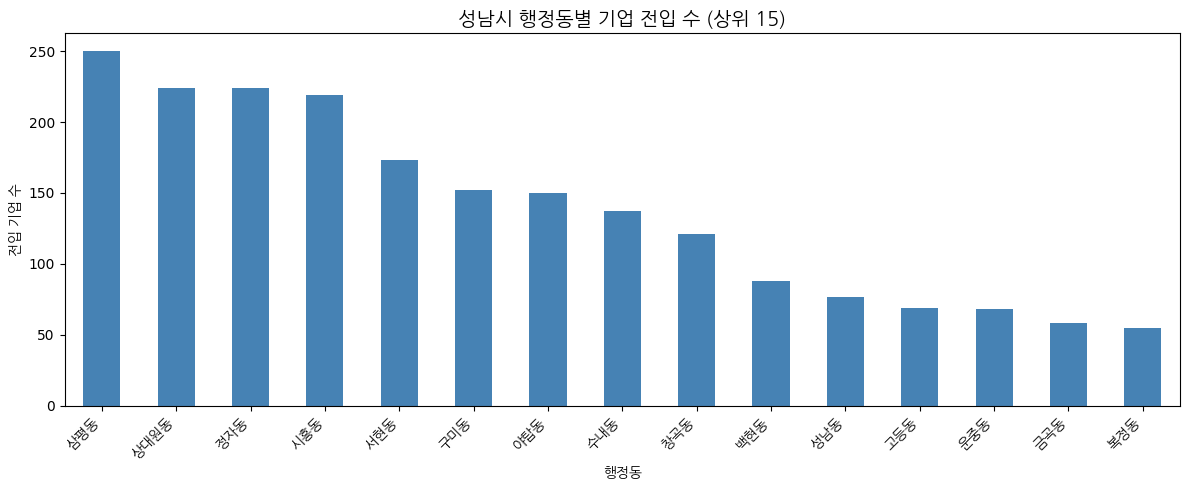

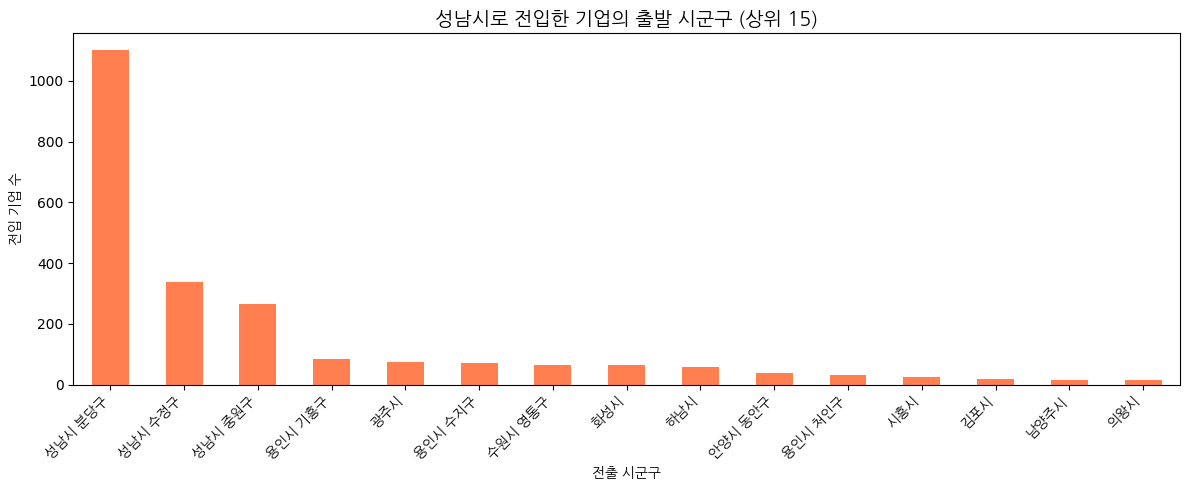

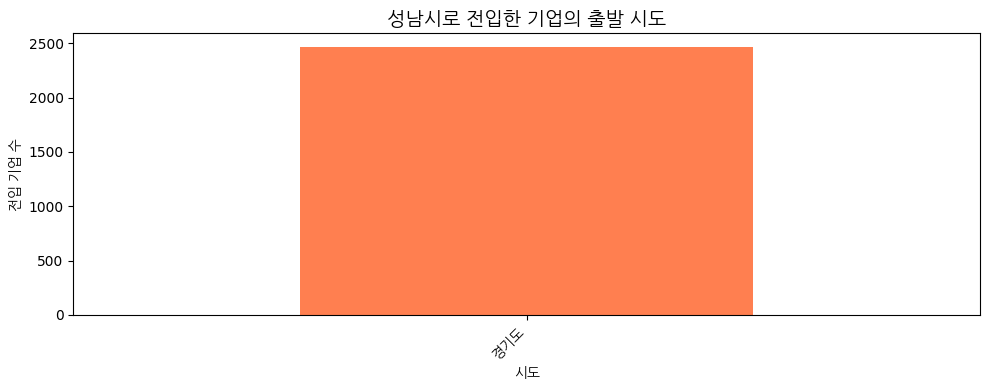

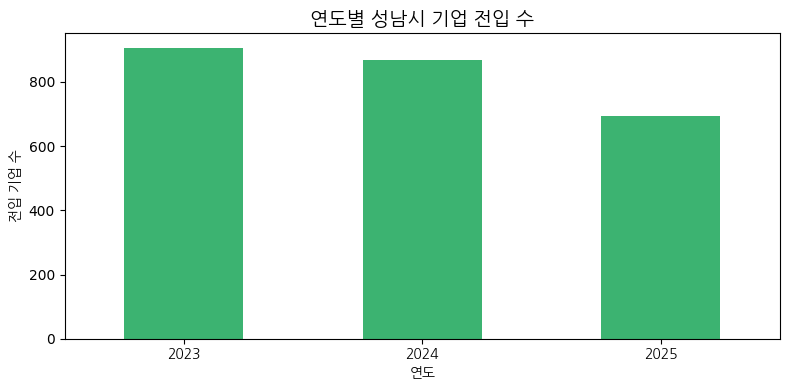

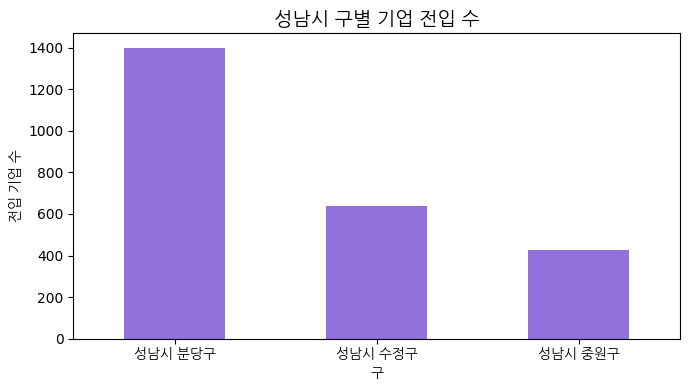

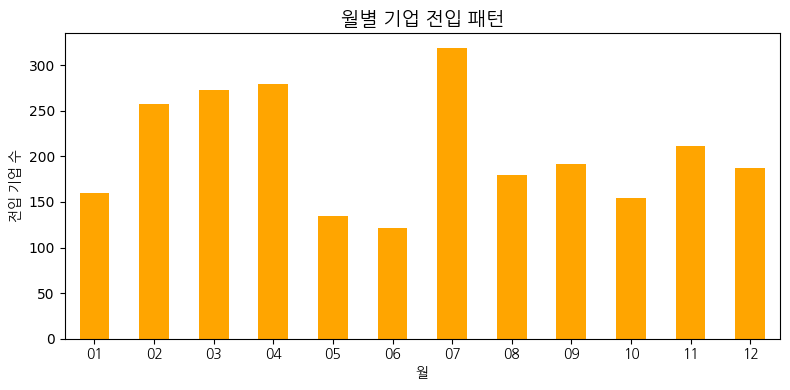

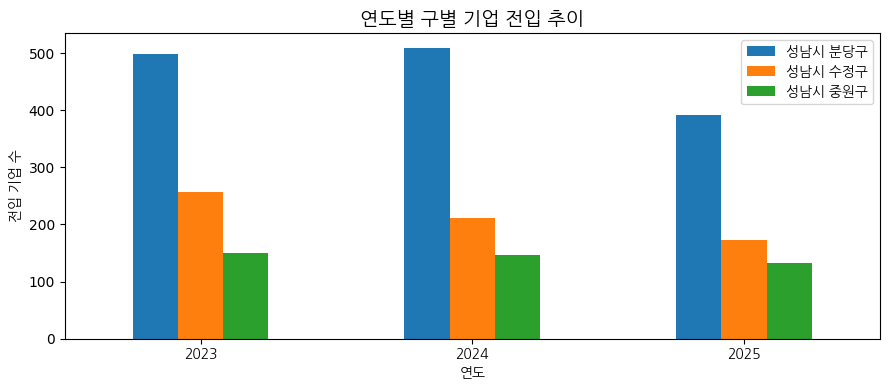

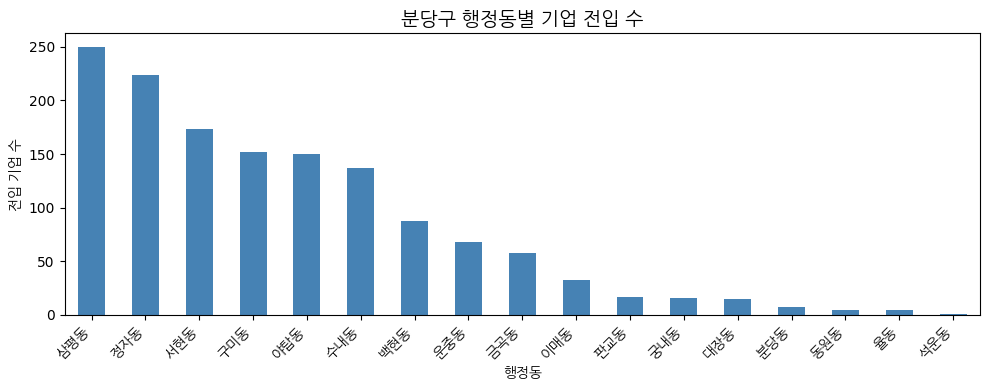

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 한글 폰트
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
fontprop = fm.FontProperties(fname=font_path)
mpl.rcParams['axes.unicode_minus'] = False

# ── 전처리 ───────────────────────────────────────────────────
df["stdr_ym"] = df["stdr_ym"].astype(str)
df["year"] = df["stdr_ym"].str[:4]
df["month"] = df["stdr_ym"].str[4:6]
df_in = df[df["in_sigun_nm"].str.contains("성남", na=False)].copy()

# ── 집계 ─────────────────────────────────────────────────────
admi_in       = df_in.groupby("in_admi_nm")["comp_cn"].sum().sort_values(ascending=False)
out_sigun     = df_in.groupby("out_sigun_nm")["comp_cn"].sum().sort_values(ascending=False)
out_sido      = df_in.groupby("out_sido_nm")["comp_cn"].sum().sort_values(ascending=False)
year_trend    = df_in.groupby("year")["comp_cn"].sum()
gu_in         = df_in.groupby("in_sigun_nm")["comp_cn"].sum()
month_trend   = df_in.groupby("month")["comp_cn"].sum()
gu_year       = df_in.groupby(["year", "in_sigun_nm"])["comp_cn"].sum().unstack()
df_bundang    = df_in[df_in["in_sigun_nm"] == "성남시 분당구"]
admi_bundang  = df_bundang.groupby("in_admi_nm")["comp_cn"].sum().sort_values(ascending=False)

# ── 그래프 1 : 행정동별 전입 수 (상위 15) ───────────────────
fig, ax = plt.subplots(figsize=(12, 5))
admi_in.head(15).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("성남시 행정동별 기업 전입 수 (상위 15)", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("행정동", fontproperties=fontprop)
ax.set_ylabel("전입 기업 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── 그래프 2 : 전출 시군구 (상위 15) ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
out_sigun.head(15).plot(kind="bar", ax=ax, color="coral")
ax.set_title("성남시로 전입한 기업의 출발 시군구 (상위 15)", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("전출 시군구", fontproperties=fontprop)
ax.set_ylabel("전입 기업 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── 그래프 3 : 전출 시도별 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
out_sido.plot(kind="bar", ax=ax, color="coral")
ax.set_title("성남시로 전입한 기업의 출발 시도", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("시도", fontproperties=fontprop)
ax.set_ylabel("전입 기업 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── 그래프 4 : 연도별 전입 트렌드 ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
year_trend.plot(kind="bar", ax=ax, color="mediumseagreen")
ax.set_title("연도별 성남시 기업 전입 수", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("연도", fontproperties=fontprop)
ax.set_ylabel("전입 기업 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()

# ── 그래프 5 : 구별 전입 비교 ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
gu_in.sort_values(ascending=False).plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("성남시 구별 기업 전입 수", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("구", fontproperties=fontprop)
ax.set_ylabel("전입 기업 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()

# ── 그래프 6 : 월별 패턴 ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
month_trend.plot(kind="bar", ax=ax, color="orange")
ax.set_title("월별 기업 전입 패턴", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("월", fontproperties=fontprop)
ax.set_ylabel("전입 기업 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
plt.tight_layout()
plt.show()

# ── 그래프 7 : 연도별 구별 트렌드 ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
gu_year.plot(kind="bar", ax=ax)
ax.set_title("연도별 구별 기업 전입 추이", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("연도", fontproperties=fontprop)
ax.set_ylabel("전입 기업 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=0)
ax.legend(prop=fontprop)
plt.tight_layout()
plt.show()

# ── 그래프 8 : 분당구 행정동별 ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
admi_bundang.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("분당구 행정동별 기업 전입 수", fontproperties=fontprop, fontsize=14)
ax.set_xlabel("행정동", fontproperties=fontprop)
ax.set_ylabel("전입 기업 수", fontproperties=fontprop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=fontprop, rotation=45, ha="right")
plt.tight_layout()
plt.show()